# Fase 1.5: Adaptación de Dominio (Fotografías en Entorno de Prueba)

**Objetivo:** Multiplicar las 30 muestras fotográficas del objeto impreso en formato A4 (`dataset/imgs/`) mediante técnicas de aumentación de datos compatibles con la descripción geométrica del descriptor HOG.

### Fundamentación Técnica (Domain Adaptation)
La incorporación de muestras tomadas con los sensores ópticos y las condiciones lumínicas del entorno de evaluación local permite disminuir el error de generalización entre el conjunto de entrenamiento sintético/web y las condiciones de captura en tiempo real.

### Balanceo de Clases y Tasa de Aumentación
El conjunto de datos positivo base cuenta con **3,885 imágenes**.
- Un factor de aumentación 1x (30 imágenes) representaría únicamente el **0.7%** de la clase positiva, teniendo un impacto estadístico nulo en el hiperplano del clasificador.
- Un factor de aumentación masivo (ej. 100x con 3,000 imágenes) induciría **sobreajuste (overfitting)** hacia las características específicas del papel y el entorno de fondo inmediato.
- **Factor de aumentación seleccionado (10x - 300 imágenes):** Representa aproximadamente el **7.2%** del conjunto de entrenamiento positivo. Esta proporción permite integrar la variabilidad del entorno de prueba manteniendo la capacidad de generalización del modelo HOG+SVM.

--- 
### Criterios de Selección de Transformaciones para HOG
El descriptor HOG computa histogramas de gradientes orientados localmente, siendo altamente sensible a la pérdida de nitidez y a modificaciones geométricas extremas.

| Transformaciones No Recomendadas | Transformaciones Implementadas |
|---|---|
| **Filtros de desenfoque (Blur / GaussianBlur) y Ruido:** Atenúan los gradientes de alta frecuencia. La pérdida de nitidez degrada el cómputo de gradientes de orientación en las celdas HOG. | **Inversión Horizontal (Horizontal Flip):** Preserva la geometría y gradientes del vehículo, duplicando la variabilidad direccional de forma neutra. |
| **Inversión Vertical (Vertical Flip):** Altera la semántica estructural del objeto (ej. ruedas en la parte superior), generando vectores de características no válidos. | **Ajuste Aleatorio de Brillo y Contraste (±18%):** Simula variaciones de iluminación local, sombras proyectadas y reflejos en la superficie del papel. |
| **Rotaciones severas (>15°):** Convierten componentes estructurales horizontales (techo, chasis) en componentes diagonales, modificando drásticamente el histograma resultante. | **Transformación Afín Leve (Rotación ±7°, Escala ±5%):** Simula pequeñas inclinaciones y variaciones de distancia durante la sujeción manual de la muestra. |

In [1]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

# Asegurar que el entorno de ejecución se ubique en el directorio raíz del proyecto
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Directorio de trabajo actual:", os.getcwd())

# Importación o instalación condicional de la librería de aumentación de datos
try:
    import albumentations as A
except ImportError:
    print("Instalando librería Albumentations...")
    !pip install -q albumentations
    import albumentations as A

print("Albumentations listo para procesamiento.")

Directorio de trabajo actual: /Users/andresmorocho/Downloads/Vision/practicas/stereo_project/parte2_detector
Albumentations listo para procesamiento.


In [2]:
# 1. Configuración del pipeline de transformaciones afines y fotométricas
# Parámetros ajustados para no alterar la magnitud de los gradientes en el descriptor HOG
hog_safe_transform = A.Compose([
    # Inversión horizontal (probabilidad del 50%)
    A.HorizontalFlip(p=0.5),
    
    # Rotación e inclinación moderadas (máximo ±7 grados, escala ±5%)
    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.05, rotate_limit=7, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),
    
    # Modificación controlada de brillo y contraste (±18%)
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.8),
    
    # Variación cromática leve en el espacio HSV
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.5)
])

print("Pipeline de aumentación optimizado para HOG configurado.")

Pipeline de aumentación optimizado para HOG configurado.


/Users/andresmorocho/miniconda3/envs/vision/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/h_/rtmt73f52zl2v71m1w2kf0tw0000gn/T/ipykernel_259/39361793.py:8: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.05, rotate_limit=7, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.7),


In [ ]:
# 2. Procesamiento masivo e iterativo del conjunto de muestras capturadas
input_dir = "dataset/imgs"
output_dir = "dataset/positives"
variations_per_image = 10  # Generación de 10 variaciones por imagen (30 x 10 = 300 muestras)

os.makedirs(output_dir, exist_ok=True)

# Limpieza de ejecuciones previas para mantener la reproducibilidad del dataset
old_augs = glob.glob(os.path.join(output_dir, "aug_paper_*.jpg"))
for old_file in old_augs:
    os.remove(old_file)
if old_augs:
    print(f"Se eliminaron {len(old_augs)} archivos previos para ejecución limpia.")

# Lectura de archivos fuente en el directorio de entrada
img_files = glob.glob(os.path.join(input_dir, "*.jpg")) + glob.glob(os.path.join(input_dir, "*.png"))
print(f"Procesando {len(img_files)} imágenes base en '{input_dir}'...")

generated_count = 0
for idx, img_path in enumerate(img_files):
    # Carga en formato BGR y conversión a RGB para la librería Albumentations
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    
    # Aplicación iterativa de transformaciones
    for v in range(variations_per_image):
        augmented = hog_safe_transform(image=img_rgb)['image']
        
        # Retorno al espacio BGR para almacenamiento local con OpenCV
        aug_bgr = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        
        out_name = f"aug_paper_{generated_count:04d}_{base_name}_v{v}.jpg"
        out_path = os.path.join(output_dir, out_name)
        cv2.imwrite(out_path, aug_bgr)
        generated_count += 1

print(f"\nProcesamiento finalizado. Se generaron {generated_count} muestras positivas incrementales.")
print(f"Archivos almacenados en '{output_dir}' (prefijo: aug_paper_).")

Procesando 30 imágenes base en 'dataset/imgs'...

Procesamiento finalizado. Se generaron 300 muestras positivas incrementales.
Archivos almacenados en 'dataset/test' (prefijo: aug_paper_).


Visualización de control aleatorio de muestras generadas:


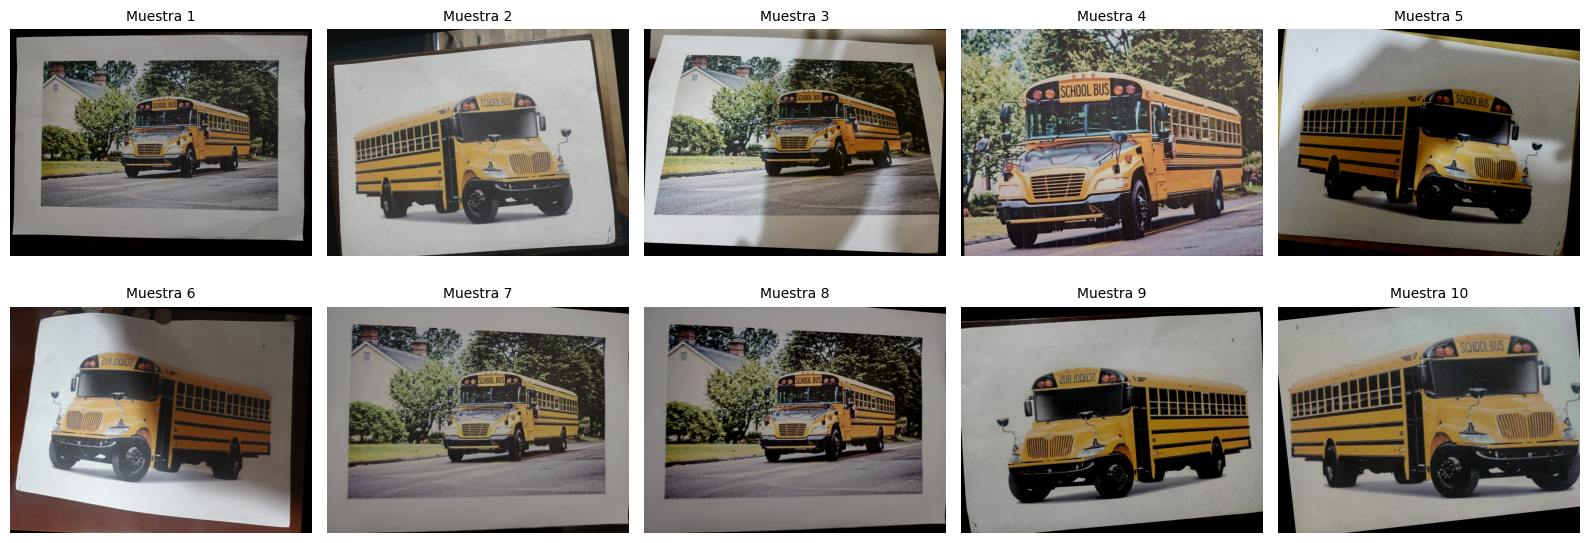

In [4]:
# 3. Muestreo aleatorio y verificación visual de las imágenes resultantes
print("Visualización de control aleatorio de muestras generadas:")
new_augs = glob.glob(os.path.join(output_dir, "aug_paper_*.jpg"))

if len(new_augs) >= 10:
    sample_augs = random.sample(new_augs, 10)
    fig, axs = plt.subplots(2, 5, figsize=(16, 6))
    for i, ax in enumerate(axs.flat):
        img = cv2.imread(sample_augs[i])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Muestra {i+1}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()